# NLP with Deep Learning

In [1]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [2]:
df = pd.read_csv('yelp.csv')

<Axes: xlabel='stars', ylabel='count'>

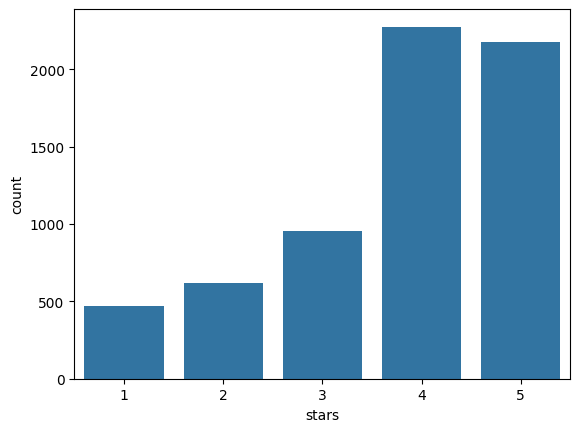

In [3]:
sns.countplot(x=df['stars'])

In [4]:
df['text']=df['text'].str.lower() # küçük harfe çevirme
df['text']=df['text'].str.replace('[^\w\s]','', regex = True) # noktalama işaretlerini kaldırır
df['text']=df['text'].str.replace('\d+','', regex = True) # rakamları kaldırır
df['text']=df['text'].str.replace('\n','', regex = True) # satır sonlarını kaldırır
df['text']=df['text'].str.replace('\r','', regex = True) # enterları kaldırır

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9662/2140159025.py:2: SyntaxWarning: invalid escape sequence '\w'
  df['text']=df['text'].str.replace('[^\w\s]','', regex = True) # noktalama işaretlerini kaldırır
/tmp/ipykernel_9662/2140159025.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['text']=df['text'].str.replace('\d+','', regex = True) # rakamları kaldırır


In [5]:
ybw = df[(df.stars==1) | (df.stars==5)]

In [6]:
ybw.reset_index(drop=True, inplace=True) # index düzeltme

In [7]:
df

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,my wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2.0,5.0,0.0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,i have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0.0,0.0,0.0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate rice is so good and i also...,review,0hT2KtfLiobPvh6cDC8JQg,0.0,1.0,0.0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,rosie dakota and i love chaparral dog park its...,review,uZetl9T0NcROGOyFfughhg,1.0,2.0,0.0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,general manager scott petello is a good egg no...,review,vYmM4KTsC8ZfQBg-j5MWkw,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
6493,rZbHg4ACfN3iShdsT47WKQ,2012-10-23,K5OlX0wlxujb-GPOMiz4TQ,5,the perfect burger awesome bbq never a bad meal,review,Vibtr-_DiDbwZqaxKK8SYw,0.0,0.0,0.0
6494,l3yL2rQ6PoFBQ06RLczn9w,2010-08-08,nallZ2KPMBbdZ2_nvTB8Ig,4,despite all the recent bad reviews of this pla...,review,Yk37VAp452K7FwHWd1rrQw,2.0,1.0,1.0
6495,l0S5b8YYyDbjttTWtKc-gg,2012-06-20,ZpkGGIcD1zX5Pc4p4c93fA,5,whyd the chicken cross the roadto get to food ...,review,cRyNICH0mhjxagvSyVr60Q,27.0,31.0,24.0
6496,iAHNZo6GF4C3N-z8u2C_ww,2009-07-17,uGLJc7uFKY6J1-YSf6nzhg,4,i forgot they built a bunch of ff places along...,review,n_lAaNGeWgspbbCJc0DqRg,6.0,7.0,6.0


In [8]:
x=ybw['text']
y=ybw[['stars']]

In [9]:
d={1:0,5:1}

In [10]:
y['stars']=y['stars'].map(d)

/tmp/ipykernel_9662/361118301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['stars']=y['stars'].map(d)


<Axes: xlabel='stars', ylabel='count'>

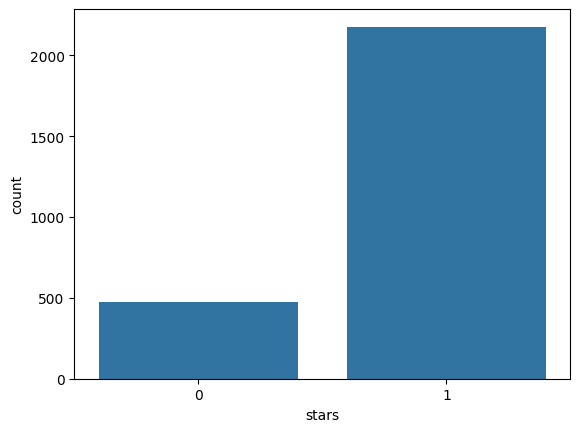

In [11]:
sns.countplot(x=y['stars'])

In [12]:
def ekkok(text):
    words=TextBlob(text).words
    return [word.lemmatize() for word in words]

In [13]:
vect=CountVectorizer(stop_words='english', analyzer=ekkok,ngram_range=(1,2))

In [14]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(
    analyzer='word',
    stop_words='english',
    ngram_range=(1,2)
)

x_vect = vect.fit_transform(x).toarray()

In [16]:
tf=pd.DataFrame(vect.fit_transform(x).toarray(), columns=vect.get_feature_names_out())

In [17]:
tf # BAG of words, word embeddings Bert , Alberta, mistrial

,aa,aa accessories,aa coming,aa good,aa prices,aa supports,aaa,aaa bail,aaaamazingthey,aaaamazingthey best,...,zuzus,zuzus room,zwiebelkräuter,zwiebelkräuter salat,éclairs,éclairs napoleons,école,école lenôtre,ém,ém huge
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2645,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2646,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2647,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x_vect, y, test_size=0.20, random_state=42)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
model=Sequential([
    Dense(256, activation='relu'), # hayal urunu Black box nature of DL
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # classification son layer sigmoid eger 1-0 ise softmax 2 den fazla secenek icin
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), verbose=2, epochs=15)

Epoch 1/15
67/67 - 21s - 316ms/step - accuracy: 0.8386 - loss: 0.3852 - val_accuracy: 0.9057 - val_loss: 0.2279
Epoch 2/15
67/67 - 4s - 57ms/step - accuracy: 0.9910 - loss: 0.0372 - val_accuracy: 0.9396 - val_loss: 0.2837
Epoch 3/15
67/67 - 4s - 65ms/step - accuracy: 0.9986 - loss: 0.0041 - val_accuracy: 0.9057 - val_loss: 0.4085
Epoch 4/15
67/67 - 4s - 52ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.8981 - val_loss: 0.8770
Epoch 5/15
67/67 - 3s - 43ms/step - accuracy: 1.0000 - loss: 6.7303e-04 - val_accuracy: 0.9358 - val_loss: 0.4590
Epoch 6/15
67/67 - 5s - 75ms/step - accuracy: 1.0000 - loss: 2.6497e-04 - val_accuracy: 0.9340 - val_loss: 0.4740
Epoch 7/15
67/67 - 2s - 35ms/step - accuracy: 1.0000 - loss: 1.7402e-04 - val_accuracy: 0.9358 - val_loss: 0.4905
Epoch 8/15
67/67 - 2s - 35ms/step - accuracy: 1.0000 - loss: 1.1808e-04 - val_accuracy: 0.9377 - val_loss: 0.5080
Epoch 9/15
67/67 - 3s - 38ms/step - accuracy: 1.0000 - loss: 7.5209e-05 - val_accuracy: 0.9377 - val_l

In [22]:
model.evaluate(x_test, y_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9396 - loss: 0.6815


[0.681474506855011, 0.9396226406097412]

In [24]:
neg = df[df['stars'] == 1]['text'].iloc[0]

In [25]:
pos=df[df['stars']==5]['text'].iloc[0]

In [26]:
text1=vect.transform([pos]).toarray()

In [27]:
text2=vect.transform([neg]).toarray()

In [28]:
p1=model.predict(text1)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step


In [29]:
p2=model.predict(text2)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [30]:
label=['Negative','Positive']

In [31]:
label[p1]

'Positive'

In [32]:
label[p2]

'Negative'

In [33]:
model.save('sentiment.keras')

In [34]:
from keras.models import load_model

In [35]:
model2=load_model('sentiment.keras')

In [36]:
p3=model2.predict(text1)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step


In [37]:
p3=model2.predict(text1)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


## NLP with Neat Text

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv('yelp.csv')

In [40]:
pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 6.2 MB/s eta 0:00:00


In [41]:
df['text']

,text
0,My wife took me here on my birthday for breakf...
1,I have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,General Manager Scott Petello is a good egg!!!...
...,...
9995,First visit...Had lunch here today - used my G...
9996,Should be called house of deliciousness!\n\nI ...
9997,I recently visited Olive and Ivy for business ...
9998,My nephew just moved to Scottsdale recently so...


In [46]:
s=' '.join(df['text'])

In [47]:
from collections import Counter

In [49]:
Counter(s.split())

Counter({'My': 2036,
         'wife': 298,
         'took': 722,
         'me': 3509,
         'here': 2945,
         'on': 8681,
         'my': 9062,
         'birthday': 132,
         'for': 14327,
         'breakfast': 492,
         'and': 42015,
         'it': 11738,
         'was': 19627,
         'excellent.': 166,
         'The': 11418,
         'weather': 68,
         'perfect': 414,
         'which': 2613,
         'made': 1204,
         'sitting': 254,
         'outside': 401,
         'overlooking': 9,
         'their': 3433,
         'grounds': 30,
         'an': 2914,
         'absolute': 52,
         'pleasure.': 10,
         'Our': 489,
         'waitress': 355,
         'excellent': 338,
         'our': 2840,
         'food': 4004,
         'arrived': 203,
         'quickly': 170,
         'the': 54809,
         'semi-busy': 1,
         'Saturday': 239,
         'morning.': 47,
         'It': 2662,
         'looked': 448,
         'like': 4578,
         'place': 5133,
 

In [50]:
import neattext.functions as nfx

In [51]:
s2 = nfx.remove_stopwords(s)

In [53]:
Counter(s2.split())

Counter({'wife': 298,
         'took': 722,
         'birthday': 132,
         'breakfast': 492,
         'excellent.': 166,
         'weather': 68,
         'perfect': 414,
         'sitting': 254,
         'outside': 401,
         'overlooking': 9,
         'grounds': 30,
         'absolute': 52,
         'pleasure.': 10,
         'waitress': 355,
         'excellent': 338,
         'food': 4004,
         'arrived': 203,
         'quickly': 170,
         'semi-busy': 1,
         'Saturday': 239,
         'morning.': 47,
         'looked': 448,
         'like': 4578,
         'place': 5133,
         'fills': 15,
         'pretty': 1686,
         'earlier': 54,
         'better.': 244,
         'favor': 33,
         'Bloody': 20,
         'Mary.': 3,
         'phenomenal': 20,
         'simply': 143,
         'best': 1435,
         "I've": 1998,
         'had.': 206,
         "I'm": 2083,
         'sure': 930,
         'use': 439,
         'ingredients': 189,
         'garden': 38,
   

In [55]:
data=Counter(s2.split()).most_common(20) # en cok tekrar eden 20 kelime

In [56]:
data = dict(data)

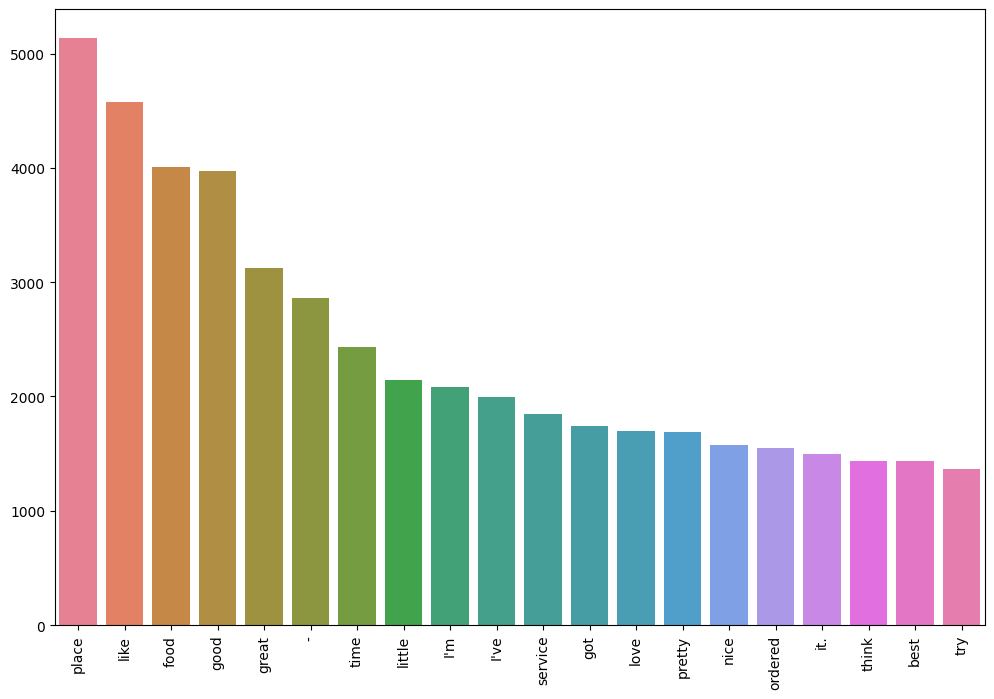

In [59]:
plt.figure(figsize=(12,8))
sns.barplot(x=data.keys(),y=data.values(), hue=data.keys())
plt.xticks(rotation=90);

In [61]:
iyi=df[df['stars']==5]

In [62]:
iyic=' '.join(iyi['text'])

In [63]:
iyic=nfx.remove_stopwords(iyic)

In [64]:
data=Counter(iyic.split()).most_common(20)

In [65]:
data=dict(data)

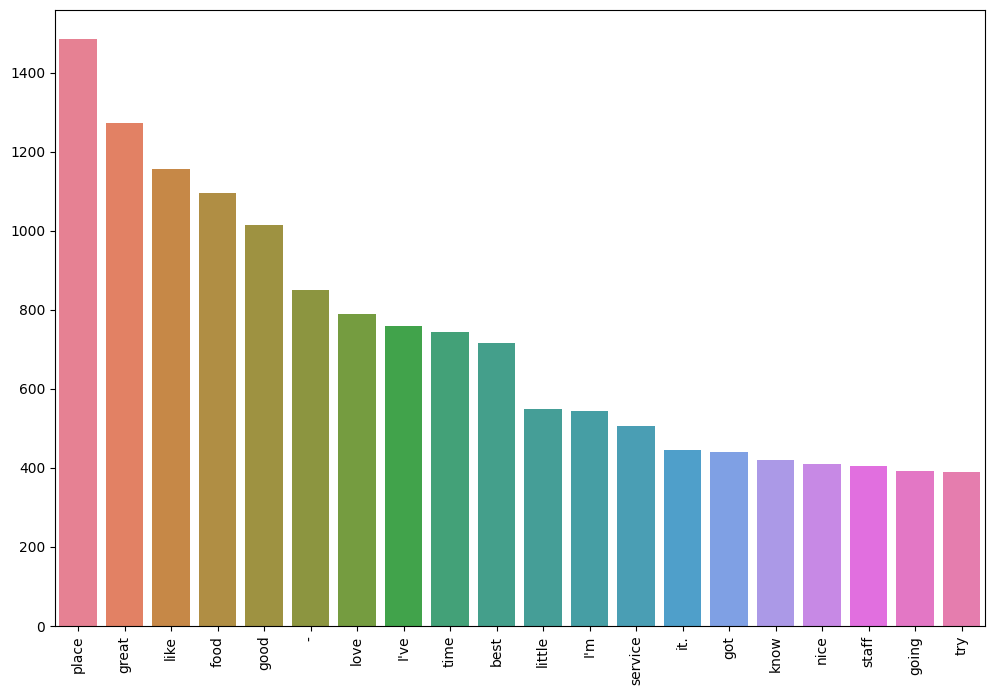

In [66]:
plt.figure(figsize=(12,8))
sns.barplot(x=data.keys(),y=data.values(), hue=data.keys())
plt.xticks(rotation=90);